####Installation & Imports

In [4]:
!pip install -q transformers accelerate bitsandbytes sentencepiece protobuf

In [5]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline,
    BitsAndBytesConfig
)
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"


In [6]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

####Load Data

In [8]:
main_directory = '/content/drive/MyDrive/Barnabus Project/'
df = pd.read_csv(f'{main_directory}data/processed/analyzed_data.csv')
print(f"Loaded data: {df.shape}")
print(f"   Clusters: {df['cluster'].nunique()}")
print(f"   Samples: {len(df)}")

cluster_info = pd.read_csv(f'{main_directory}outputs/cluster_info.csv')

Loaded data: (6000, 16)
   Clusters: 20
   Samples: 6000


####Load LLM

In [9]:
!pip install -U bitsandbytes

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"
print(f"Loading model: {model_name}")
print("   Using 4-bit quantization for T4 GPU compatibility...")


tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

print("Model loaded successfully")
print("   Model size: ~4GB (quantized)")

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.3,  # Low temperature for consistent, formal output
    top_p=0.9,
    repetition_penalty=1.15
)

Loading model: mistralai/Mistral-7B-Instruct-v0.2
   Using 4-bit quantization for T4 GPU compatibility...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Device set to use cuda:0


Model loaded successfully
   Model size: ~4GB (quantized)


In [11]:
SUMMARY_PROMPT_TEMPLATE = """You are writing an internal hospital service report.
                              Summarize the following cluster of patient comments in exactly 2 plain sentences.
                              Sentence 1 must start with this exact phrase:
                              'Main issues of the patients in this topic were '
                              and then list recurring issues or observations (general, impersonal).
                              Sentence 2 should state overall sentiment or operational implication.
                              Use a neutral, factual, clinical tone.
                              Do not reference people, journalists, organizations, articles, locations, or outside events.
                              Do not use pronouns, names, dates, or greetings.
                              Do not invent information. Avoid introductions like 'Welcome', 'Overall', or 'In summary'.

TEXT:
{text}

SUMMARY:"""

print("Prompt template configured")
print("\nTemplate preview:")
print(SUMMARY_PROMPT_TEMPLATE.split("TEXT:")[0])

Prompt template configured

Template preview:
You are writing an internal hospital service report.
                              Summarize the following cluster of patient comments in exactly 2 plain sentences.
                              Sentence 1 must start with this exact phrase:
                              'Main issues of the patients in this topic were '
                              and then list recurring issues or observations (general, impersonal).
                              Sentence 2 should state overall sentiment or operational implication.
                              Use a neutral, factual, clinical tone.
                              Do not reference people, journalists, organizations, articles, locations, or outside events.
                              Do not use pronouns, names, dates, or greetings.
                              Do not invent information. Avoid introductions like 'Welcome', 'Overall', or 'In summary'.




In [12]:
def prepare_cluster_text(cluster_df, max_samples=30, max_chars_per_sample=200):
    """
    Prepare representative text from a cluster for summarization

    Args:
        cluster_df: DataFrame with cluster samples
        max_samples: Maximum number of samples to include
        max_chars_per_sample: Max characters per sample

    Returns:
        Combined text string
    """
    if len(cluster_df) > max_samples:
        sampled = cluster_df.groupby('sentiment', group_keys=False).apply(
            lambda x: x.sample(min(len(x), max_samples // 3), random_state=RANDOM_STATE)
        ).head(max_samples)
    else:
        sampled = cluster_df

    texts = []
    for _, row in sampled.iterrows():
        text = row['text_final'] if pd.notna(row['text_final']) else row['text_cleaned']
        if text and len(text) > 20:
            text = text[:max_chars_per_sample]
            texts.append(f"- {text}")

    return "\n".join(texts)


cluster_texts = {}
print("Preparing texts for each cluster...")

for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id]
    cluster_text = prepare_cluster_text(cluster_df, max_samples=25)
    cluster_texts[cluster_id] = cluster_text

    print(f"Cluster {cluster_id}: {len(cluster_df)} samples -> {len(cluster_text)} chars prepared")


Preparing texts for each cluster...
Cluster 0: 440 samples -> 4710 chars prepared
Cluster 1: 276 samples -> 4534 chars prepared
Cluster 2: 466 samples -> 4450 chars prepared
Cluster 3: 287 samples -> 3001 chars prepared
Cluster 4: 305 samples -> 4345 chars prepared
Cluster 5: 291 samples -> 4446 chars prepared
Cluster 6: 416 samples -> 1833 chars prepared
Cluster 7: 135 samples -> 4608 chars prepared
Cluster 8: 399 samples -> 4617 chars prepared
Cluster 9: 316 samples -> 3438 chars prepared
Cluster 10: 352 samples -> 3812 chars prepared
Cluster 11: 168 samples -> 1833 chars prepared
Cluster 12: 211 samples -> 3039 chars prepared
Cluster 13: 299 samples -> 4256 chars prepared
Cluster 14: 317 samples -> 4616 chars prepared
Cluster 15: 133 samples -> 4668 chars prepared
Cluster 16: 205 samples -> 4236 chars prepared
Cluster 17: 346 samples -> 4360 chars prepared
Cluster 18: 375 samples -> 4653 chars prepared
Cluster 19: 263 samples -> 2549 chars prepared


In [13]:
def generate_summary(text, max_retries=3):
    """
    Generate summary using LLM with retry logic
    """
    prompt = SUMMARY_PROMPT_TEMPLATE.format(text=text)

    for attempt in range(max_retries):
        try:
            # Generate
            result = generator(
                prompt,
                max_new_tokens=200,
                num_return_sequences=1,
                pad_token_id=tokenizer.eos_token_id
            )

            # Extract generated text
            generated = result[0]['generated_text']

            if "SUMMARY:" in generated:
                summary = generated.split("SUMMARY:")[-1].strip()
            else:
                summary = generated[len(prompt):].strip()

            summary = summary.split("\n\n")[0]
            summary = summary.strip()

            if not summary.lower().startswith("main issues"):
                if "main issues" in summary.lower():
                    summary = "Main issues of the patients in this topic were " + summary.split("main issues", 1)[1]
                else:
                    if attempt < max_retries - 1:
                        continue

            return summary

        except Exception as e:
            print(f"Error on attempt {attempt + 1}: {str(e)[:100]}")
            if attempt == max_retries - 1:
                return "Summary generation failed for this cluster."

    return "Summary generation failed for this cluster."


In [14]:
cluster_summaries = {}

for cluster_id in tqdm(sorted(df['cluster'].unique()), desc="Clusters"):
    print(f"Cluster {cluster_id}...")

    cluster_text = cluster_texts[cluster_id]

    summary = generate_summary(cluster_text)
    cluster_summaries[cluster_id] = summary

    print(f"Summary: {summary[:150]}...")

Clusters:   0%|          | 0/20 [00:00<?, ?it/s]

Cluster 0...
Summary: Main issues of the patients in this topic were frequent changes in doctors and long waiting times. Overall sentiment or operational implication: Patie...
Cluster 1...
Summary: Main issues of the patients in this topic were long waiting times, perceived lack of attention from staff, and uncertainty regarding the competence of...
Cluster 2...
Summary: Main issues of the patients in this topic were concerns about trusting new doctors, unexpected costs, and variable quality of dental care, particularl...
Cluster 3...
Summary: Main issues of the patients in this topic were friendliness and professionalism of the medical staff, as well as long wait times for appointments. Ove...
Cluster 4...
Summary: Main issues of the patients in this topic were unfriendliness and lack of communication from some doctors, long wait times for appointments, and unexp...
Cluster 5...
Summary: Main issues of the patients in this topic were long waiting times and perceived lack of empathy fr

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Summary: Main issues of the patients in this topic were concerns about insufficient examination time, lack of personalized attention, and perceived old-fashion...
Cluster 10...
Summary: Main issues of the patients in this topic were long waiting times, perceived indifference, and lack of communication from some doctors. Overall, patie...
Cluster 11...
Summary: Main issues of the patients in this topic were the perceived lack of effectiveness from certain doctors within the team. Overall sentiment expressed g...
Cluster 12...
Summary: Main issues of the patients in this topic were expressing dissatisfaction with the level of communication from healthcare providers, receiving incorre...
Cluster 13...
Summary: Main issues of the patients in this topic were poor communication regarding treatments and procedures, lack of transparency in pricing, and varying le...
Cluster 14...
Summary: Main issues of the patients in this topic were miscommunication, lack of thorough examination, and long wa

In [16]:
import os
import math
import numpy as np
import pandas as pd
from ast import literal_eval

def parse_keywords(x):
    """Return a list of keywords from list/str/NaN; robust to bad formatting."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            v = literal_eval(s)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        return [t.strip() for t in s.split(",") if t.strip()]
    return []

if 'cluster' not in df.columns:
    raise KeyError("df must contain a 'cluster' column.")
if 'sentiment' not in df.columns:
    raise KeyError("df must contain a 'sentiment' column.")

if 'cluster_id' not in cluster_info.columns or 'keywords' not in cluster_info.columns:
    raise KeyError("cluster_info must contain 'cluster_id' and 'keywords' columns.")

keyword_map_raw = (
    cluster_info
    .drop_duplicates(subset=['cluster_id'])
    .set_index('cluster_id')['keywords']
    .to_dict()
)

clusters_missing_keywords = sorted(set(df['cluster'].unique()) - set(keyword_map_raw.keys()))

cluster_insights = []
n_total = len(df)

for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id]

    size = len(cluster_df)
    percentage = (size / n_total) * 100 if n_total else 0.0

    sentiment_dist = cluster_df['sentiment'].value_counts(normalize=True) * 100
    negative_pct = float(sentiment_dist.get('negative', 0.0))
    neutral_pct  = float(sentiment_dist.get('neutral',  0.0))
    positive_pct = float(sentiment_dist.get('positive', 0.0))

    if 'rating_normalized' in cluster_df.columns:
        avg_val = cluster_df['rating_normalized'].mean()
        avg_rating = None if pd.isna(avg_val) else float(avg_val)
    else:
        avg_rating = None

    kws = parse_keywords(keyword_map_raw.get(cluster_id, []))
    top_keywords = ", ".join(kws[:10]) if kws else ""

    summary = cluster_summaries.get(cluster_id, "Summary not available")

    impact_score = (negative_pct * 0.6) + (size * 0.4)

    cluster_insights.append({
        'cluster_id': cluster_id,
        'size': size,
        'percentage': round(percentage, 2),
        'negative_pct': round(negative_pct, 2),
        'neutral_pct': round(neutral_pct, 2),
        'positive_pct': round(positive_pct, 2),
        'avg_rating': None if avg_rating is None else round(avg_rating, 2),
        'top_keywords': top_keywords,
        'summary': summary,
        'impact_score': round(impact_score, 2),
    })

insights_df = pd.DataFrame(cluster_insights).sort_values('impact_score', ascending=False).reset_index(drop=True)

print(f"Compiled insights for {len(insights_df)} clusters")
print("Top 5 clusters by business impact:")
print(insights_df.head(5)[['cluster_id', 'size', 'negative_pct', 'impact_score']])

out_dir = os.path.join(main_directory, "outputs") if 'main_directory' in globals() else "./outputs"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "cluster_insights_with_summaries.csv")
insights_df.to_csv(out_path, index=False)
print("Saved:", out_path)

if clusters_missing_keywords:
    print("Note: No keywords found for cluster_ids:", clusters_missing_keywords[:20], "..."
          if len(clusters_missing_keywords) > 20 else clusters_missing_keywords)


Compiled insights for 20 clusters
Top 5 clusters by business impact:
   cluster_id  size  negative_pct  impact_score
0           0   440         37.95        198.77
1           2   466         15.67        195.80
2          18   375         37.07        172.24
3           6   416          6.97        170.58
4           8   399          8.52        164.71
Saved: /content/drive/MyDrive/Barnabus Project/outputs/cluster_insights_with_summaries.csv
Note: No keywords found for cluster_ids: [np.int64(19)] [np.int64(19)]


In [17]:
top_10_issues = insights_df.nlargest(10, 'size').copy()
top_10_issues['rank'] = range(1, 11)

print("TOP 10 RECURRING ISSUES:\n")

for _, issue in top_10_issues.iterrows():
    print(f"{int(issue['rank'])}. CLUSTER {int(issue['cluster_id'])} - {issue['size']} patients ({issue['percentage']:.1f}%)")
    print(f"   Sentiment: {issue['negative_pct']:.1f}% negative | {issue['neutral_pct']:.1f}% neutral | {issue['positive_pct']:.1f}% positive")
    if issue['avg_rating']:
        print(f"   Avg Rating: {issue['avg_rating']:.2f}/5.0")
    print(f"   Keywords: {issue['top_keywords']}")
    print(f"SUMMARY:")
    print(f"   {issue['summary']}")

top_10_issues.to_csv(f'{main_directory}outputs/top_10_recurring_issues.csv', index=False)


TOP 10 RECURRING ISSUES:

1. CLUSTER 2 - 466 patients (7.8%)
   Sentiment: 15.7% negative | 5.4% neutral | 79.0% positive
   Avg Rating: 1.00/5.0
   Keywords: الدكتور, للغاية, الطبيب, العلاج, كانت, الانتظار, بشكل, الممارسة, الوقت, très
SUMMARY:
   Main issues of the patients in this topic were concerns about trusting new doctors, unexpected costs, and variable quality of dental care, particularly regarding teeth cleanings and staff changes. Overall sentiment expressed was mixed, with some expressing satisfaction and others reporting dissatisfaction. Operational implications include addressing transparency in pricing and communication, maintaining consistent staffing, and improving patient education and reassurance during procedures.
2. CLUSTER 0 - 440 patients (7.3%)
   Sentiment: 38.0% negative | 14.8% neutral | 47.3% positive
   Avg Rating: 1.91/5.0
   Keywords: très, الأسنان, dentist, dentiste, practice, treatment, cabinet, traitement, للغاية, الدكتور
SUMMARY:
   Main issues of the 

In [18]:
sentiment_numeric_map = {'negative': -1, 'neutral': 0, 'positive': 1}
df['sentiment_numeric'] = df['sentiment'].map(sentiment_numeric_map)

cluster_sentiment_analysis = df.groupby('cluster').agg({
    'sentiment_numeric': 'mean',
    'cluster': 'count'  # size
}).rename(columns={'cluster': 'size'})

cluster_sentiment_analysis['avg_sentiment'] = cluster_sentiment_analysis['sentiment_numeric']

insights_df['avg_sentiment_score'] = insights_df['cluster_id'].map(
    cluster_sentiment_analysis['avg_sentiment'].to_dict()
)

print(" EXAMPLE INSIGHTS:")

if 'rating_normalized' in df.columns and df['rating_normalized'].notna().sum() > 0:
    overall_avg_rating = df['rating_normalized'].mean()

    low_satisfaction_clusters = insights_df[
        (insights_df['avg_rating'].notna()) &
        (insights_df['avg_rating'] < overall_avg_rating - 0.5)
    ].sort_values('avg_rating')

    if len(low_satisfaction_clusters) > 0:
        print(f"Topics with significantly lower satisfaction:")
        print(f"   Overall average rating: {overall_avg_rating:.2f}/5.0")

        for _, cluster in low_satisfaction_clusters.head(3).iterrows():
            multiplier = overall_avg_rating / cluster['avg_rating'] if cluster['avg_rating'] > 0 else 0
            print(f"\n   • Cluster {int(cluster['cluster_id'])}: {cluster['avg_rating']:.2f}/5.0 ({multiplier:.2f}× lower)")
            print(f"     Keywords: {cluster['top_keywords'][:80]}...")
            print(f"     Size: {cluster['size']} patients")

high_negative_clusters = insights_df[insights_df['negative_pct'] > 60].sort_values('negative_pct', ascending=False)

if len(high_negative_clusters) > 0:
    print(f"Topics with predominantly negative sentiment (>60%):")

    for _, cluster in high_negative_clusters.head(3).iterrows():
        print(f"\n   • Cluster {int(cluster['cluster_id'])}: {cluster['negative_pct']:.1f}% negative")
        print(f"     Keywords: {cluster['top_keywords'][:80]}...")
        print(f"     Size: {cluster['size']} patients")
        print(f"     Summary: {cluster['summary'][:120]}...")

high_positive_clusters = insights_df[insights_df['positive_pct'] > 60].sort_values('positive_pct', ascending=False)

if len(high_positive_clusters) > 0:
    print(f"Topics with predominantly positive sentiment (>60%):")

    for _, cluster in high_positive_clusters.head(3).iterrows():
        print(f"Cluster {int(cluster['cluster_id'])}: {cluster['positive_pct']:.1f}% positive")
        print(f"     Keywords: {cluster['top_keywords'][:80]}...")
        print(f"     Size: {cluster['size']} patients")


 EXAMPLE INSIGHTS:
Topics with predominantly positive sentiment (>60%):
Cluster 11: 97.0% positive
     Keywords: très, pregnancy, practice, always, grossesse, temps, good, الدكتور, للغاية, also...
     Size: 168 patients
Cluster 3: 95.5% positive
     Keywords: très, good, sympathique, للغاية, friendly, freundlich, kompetent, competent, sup...
     Size: 287 patients
Cluster 6: 88.7% positive
     Keywords: très, zeit, freundlich, immer, patienten, kompetent, competent, friendly, practi...
     Size: 416 patients


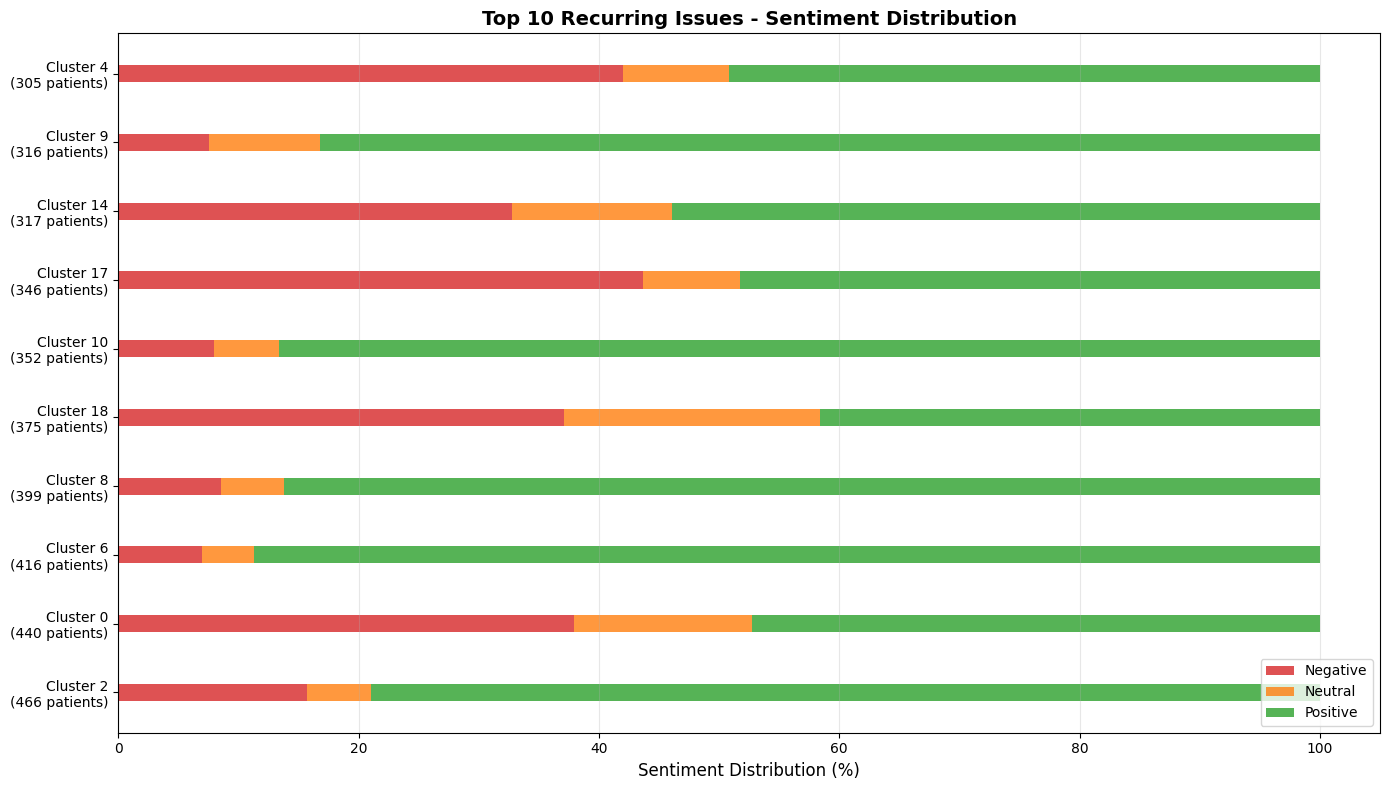

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(top_10_issues))
width = 0.25

ax.barh(x, top_10_issues['negative_pct'], width, label='Negative', color='#d62728', alpha=0.8)
ax.barh(x, top_10_issues['neutral_pct'], width, left=top_10_issues['negative_pct'],
        label='Neutral', color='#ff7f0e', alpha=0.8)
ax.barh(x, top_10_issues['positive_pct'], width,
        left=top_10_issues['negative_pct'] + top_10_issues['neutral_pct'],
        label='Positive', color='#2ca02c', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels([f"Cluster {int(c)}\n({s} patients)"
                    for c, s in zip(top_10_issues['cluster_id'], top_10_issues['size'])])
ax.set_xlabel('Sentiment Distribution (%)', fontsize=12)
ax.set_title('Top 10 Recurring Issues - Sentiment Distribution', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/11_top10_issues_sentiment.png', dpi=300, bbox_inches='tight')
plt.close()

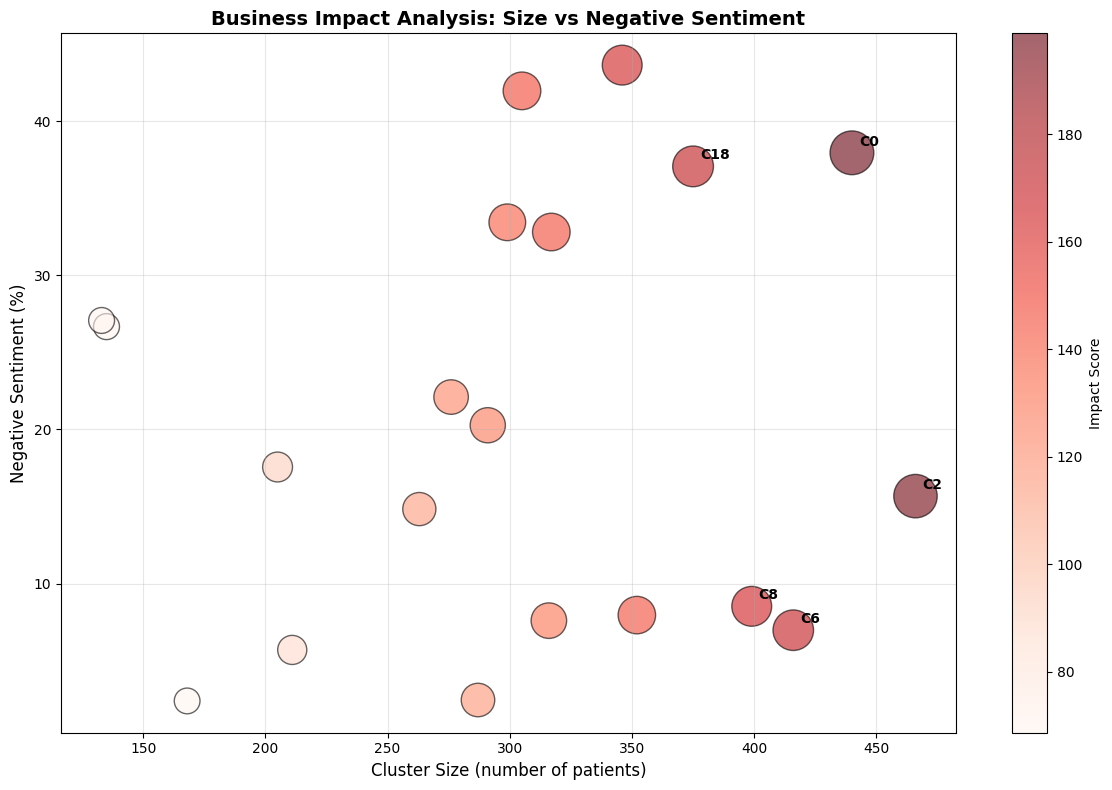

In [20]:
# 2. Impact score vs size scatter
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    insights_df['size'],
    insights_df['negative_pct'],
    s=insights_df['impact_score'] * 5,
    c=insights_df['impact_score'],
    cmap='Reds',
    alpha=0.6,
    edgecolors='black',
    linewidth=1
)

for _, row in top_10_issues.head(5).iterrows():
    ax.annotate(
        f"C{int(row['cluster_id'])}",
        (row['size'], row['negative_pct']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel('Cluster Size (number of patients)', fontsize=12)
ax.set_ylabel('Negative Sentiment (%)', fontsize=12)
ax.set_title('Business Impact Analysis: Size vs Negative Sentiment', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Impact Score')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/12_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

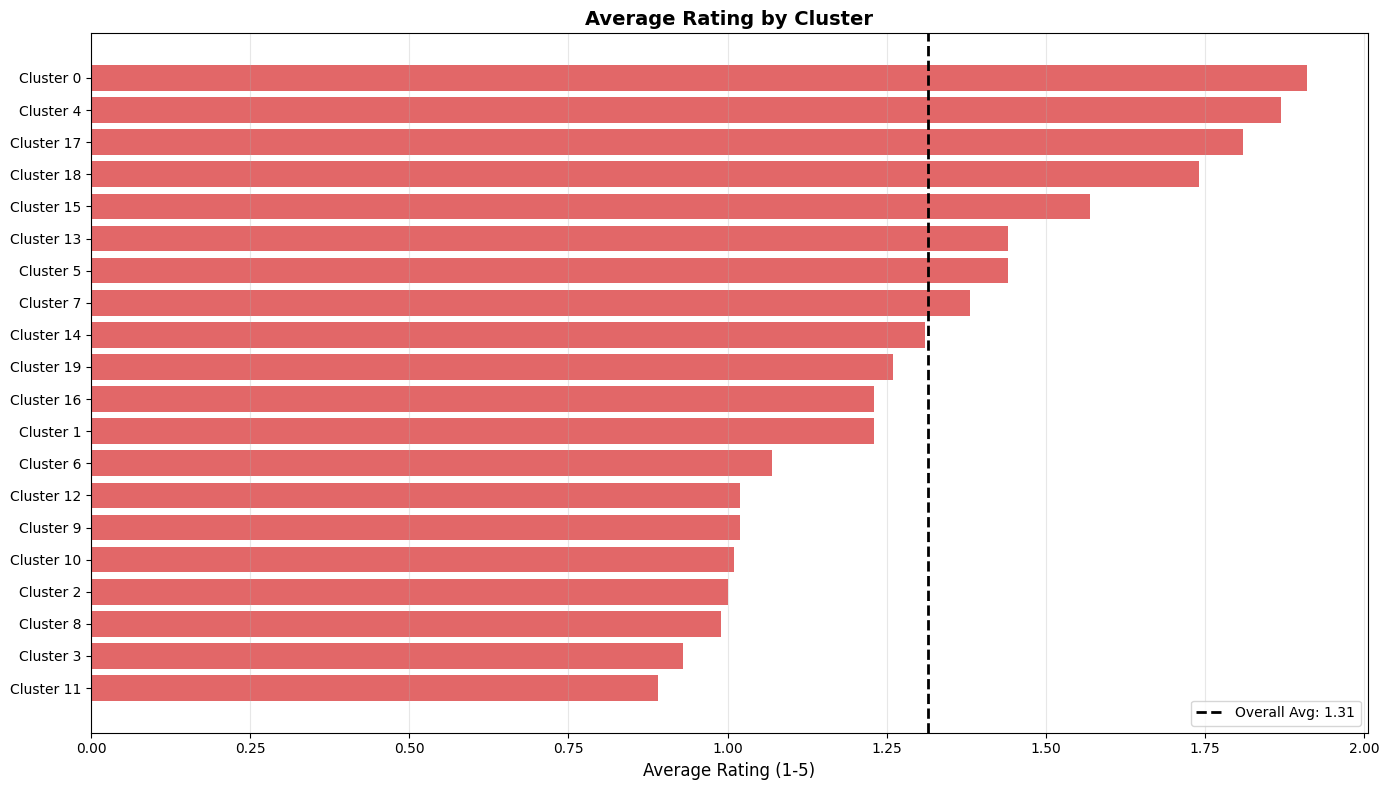

In [21]:
# 3. Rating by cluster (if available)
if 'avg_rating' in insights_df.columns and insights_df['avg_rating'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(14, 8))

    sorted_clusters = insights_df.dropna(subset=['avg_rating']).sort_values('avg_rating')

    colors = ['#d62728' if r < 3 else '#ff7f0e' if r < 4 else '#2ca02c'
              for r in sorted_clusters['avg_rating']]

    ax.barh(range(len(sorted_clusters)), sorted_clusters['avg_rating'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(sorted_clusters)))
    ax.set_yticklabels([f"Cluster {int(c)}" for c in sorted_clusters['cluster_id']])
    ax.set_xlabel('Average Rating (1-5)', fontsize=12)
    ax.set_title('Average Rating by Cluster', fontsize=14, fontweight='bold')
    ax.axvline(overall_avg_rating, color='black', linestyle='--', linewidth=2,
               label=f'Overall Avg: {overall_avg_rating:.2f}')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'{main_directory}outputs/figures/13_ratings_by_cluster.png', dpi=300, bbox_inches='tight')
    plt.close()

In [22]:
insights_df.to_csv(f'{main_directory}outputs/complete_cluster_insights.csv', index=False)

# Create executive summary
executive_summary = {
    'total_patients': len(df),
    'total_clusters': len(insights_df),
    'languages_analyzed': df['target_language'].nunique(),
    'overall_sentiment_distribution': df['sentiment'].value_counts(normalize=True).to_dict(),
    'top_3_issues': top_10_issues.head(3)[['cluster_id', 'size', 'negative_pct', 'summary']].to_dict('records'),
    'avg_rating': overall_avg_rating if 'avg_rating' in locals() else None,
    'key_insights': []
}

# Add key insights
if len(high_negative_clusters) > 0:
    executive_summary['key_insights'].append(
        f"{len(high_negative_clusters)} topics identified with predominantly negative sentiment (>60%)"
    )

if 'avg_rating' in locals():
    low_rating_count = len(low_satisfaction_clusters)
    if low_rating_count > 0:
        executive_summary['key_insights'].append(
            f"{low_rating_count} topics have significantly lower satisfaction ratings"
        )

with open(f'{main_directory}outputs/executive_summary.json', 'w') as f:
    json.dump(executive_summary, f, indent=2)

print("PHASE 4 COMPLETE: LLM SUMMARIZATION DONE")
print("\nKey outputs:")
print("1. Formal summaries generated for all clusters")
print("2. Top 10 recurring issues identified")
print("3. Sentiment vs topic analysis completed")
print("4. Business impact scores calculated")
print("5. Executive summary created")
print("\nNext steps:")
print("1. Review outputs/top_10_recurring_issues.csv")
print("2. Proceed to 05_recommendation_engine.ipynb")
print("3. Build actionable recommendations")

PHASE 4 COMPLETE: LLM SUMMARIZATION DONE

Key outputs:
1. Formal summaries generated for all clusters
2. Top 10 recurring issues identified
3. Sentiment vs topic analysis completed
4. Business impact scores calculated
5. Executive summary created

Next steps:
1. Review outputs/top_10_recurring_issues.csv
2. Proceed to 05_recommendation_engine.ipynb
3. Build actionable recommendations
